# Olist 巴西電商 SQL 分析
## Brazilian E-Commerce — SQL Exploratory Analysis

---

### 資料集
| 項目 | 說明 |
|---|---|
| 來源 | Kaggle — Brazilian E-Commerce Public Dataset by Olist |
| 時間區間 | 2016–2018 |
| 訂單數 | ~100,000 筆 |
| 資料表 | 9 張（訂單、商品、付款、評價、賣家、客戶、物流等） |

### 分析主題
1. 訂單整體概況（GMV、月趨勢）
2. 客戶分析（地理分布、回購率、LTV）
3. 賣家績效排名（Window Function：RANK）
4. 商品品類分析（多表 JOIN + 翻譯表）
5. 物流分析（配送天數、準時率）
6. 評分分析（最佳 / 最差品類）

### SQL 技術展示
`INNER / LEFT JOIN` · `CTE (WITH)` · `RANK() OVER` · `NTILE() OVER` ·
`SUM() OVER` · `CASE WHEN` · `JULIANDAY` · `strftime`

In [1]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:,.2f}'.format)

conn = sqlite3.connect('olist.db')
print("SQLite connected:", conn)

SQLite connected: <sqlite3.Connection object at 0x165cb0f40>


In [2]:
DATA_DIR = 'data'

TABLES = {
    'olist_orders':         'olist_orders_dataset.csv',
    'olist_order_items':    'olist_order_items_dataset.csv',
    'olist_order_payments': 'olist_order_payments_dataset.csv',
    'olist_order_reviews':  'olist_order_reviews_dataset.csv',
    'olist_products':       'olist_products_dataset.csv',
    'olist_sellers':        'olist_sellers_dataset.csv',
    'olist_customers':      'olist_customers_dataset.csv',
    'olist_geolocation':    'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

for table_name, filename in TABLES.items():
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    print(f"  {table_name:<32} {len(df):>8,} rows")

print("\nAll tables loaded.")

def sql(query):
    return pd.read_sql_query(query, conn)

  olist_orders                       99,441 rows


  olist_order_items                 112,650 rows
  olist_order_payments              103,886 rows


  olist_order_reviews                99,224 rows
  olist_products                     32,951 rows
  olist_sellers                       3,095 rows


  olist_customers                    99,441 rows


  olist_geolocation                1,000,163 rows
  category_translation                   71 rows

All tables loaded.


In [3]:
rows = [(t, pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn).iloc[0, 0])
        for t in TABLES]
schema = pd.DataFrame(rows, columns=["table", "rows"]).sort_values("rows", ascending=False)
schema["rows"] = schema["rows"].apply(lambda x: f"{x:,}")
schema.reset_index(drop=True)

,table,rows
0,olist_geolocation,"1,000,163"
1,olist_order_items,"112,650"
2,olist_order_payments,"103,886"
3,olist_orders,"99,441"
4,olist_customers,"99,441"
5,olist_order_reviews,"99,224"
6,olist_products,"32,951"
7,olist_sellers,"3,095"
8,category_translation,71


## Section 1：訂單整體概況

In [4]:
q = """
SELECT
    COUNT(DISTINCT o.order_id)                         AS total_orders,
    COUNT(DISTINCT c.customer_unique_id)               AS unique_customers,
    ROUND(SUM(oi.price + oi.freight_value), 0)         AS gmv_brl,
    MIN(DATE(o.order_purchase_timestamp))              AS first_order,
    MAX(DATE(o.order_purchase_timestamp))              AS last_order
FROM olist_orders      o
JOIN olist_order_items oi ON o.order_id   = oi.order_id
JOIN olist_customers    c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
"""
sql(q).T.rename(columns={0: "Value"})

,Value
total_orders,96478
unique_customers,93358
gmv_brl,"15,419,774.00"
first_order,2016-09-15
last_order,2018-08-29


/var/folders/b6/j2xnypw50xvdzgbzsn4l7p6c0000gn/T/ipykernel_98925/434439074.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/b6/j2xnypw50xvdzgbzsn4l7p6c0000gn/T/ipykernel_98925/434439074.py:28: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


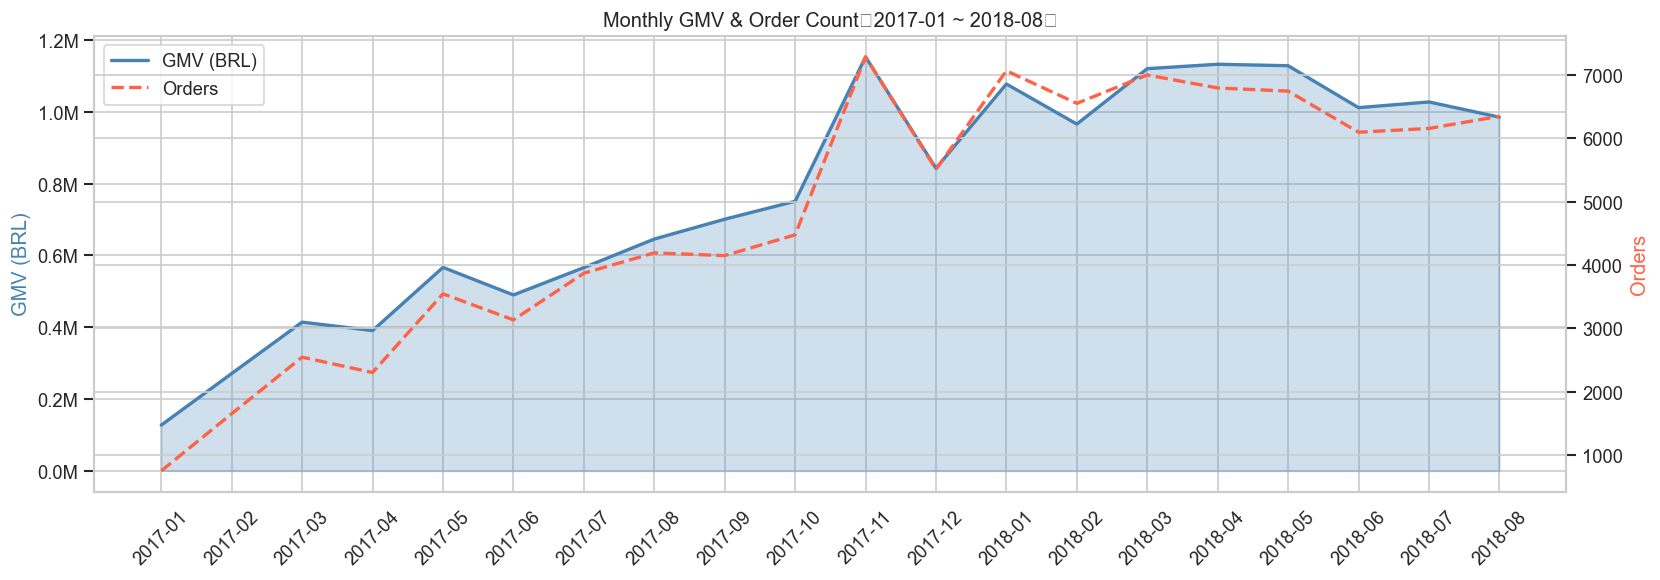

In [5]:
q = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp)   AS month,
    COUNT(DISTINCT o.order_id)                       AS orders,
    ROUND(SUM(oi.price + oi.freight_value), 0)       AS gmv
FROM olist_orders      o
JOIN olist_order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND strftime('%Y-%m', o.order_purchase_timestamp) BETWEEN '2017-01' AND '2018-08'
GROUP BY 1
ORDER BY 1
"""
monthly = sql(q)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.fill_between(monthly["month"], monthly["gmv"], alpha=0.25, color="steelblue")
ax1.plot(monthly["month"], monthly["gmv"], color="steelblue", linewidth=2, label="GMV (BRL)")
ax2.plot(monthly["month"], monthly["orders"], color="tomato", linewidth=2, linestyle="--", label="Orders")
ax1.set_ylabel("GMV (BRL)", color="steelblue")
ax2.set_ylabel("Orders", color="tomato")
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.set_title("Monthly GMV & Order Count（2017-01 ~ 2018-08）")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")
plt.tight_layout()
plt.show()

## Section 2：客戶分析

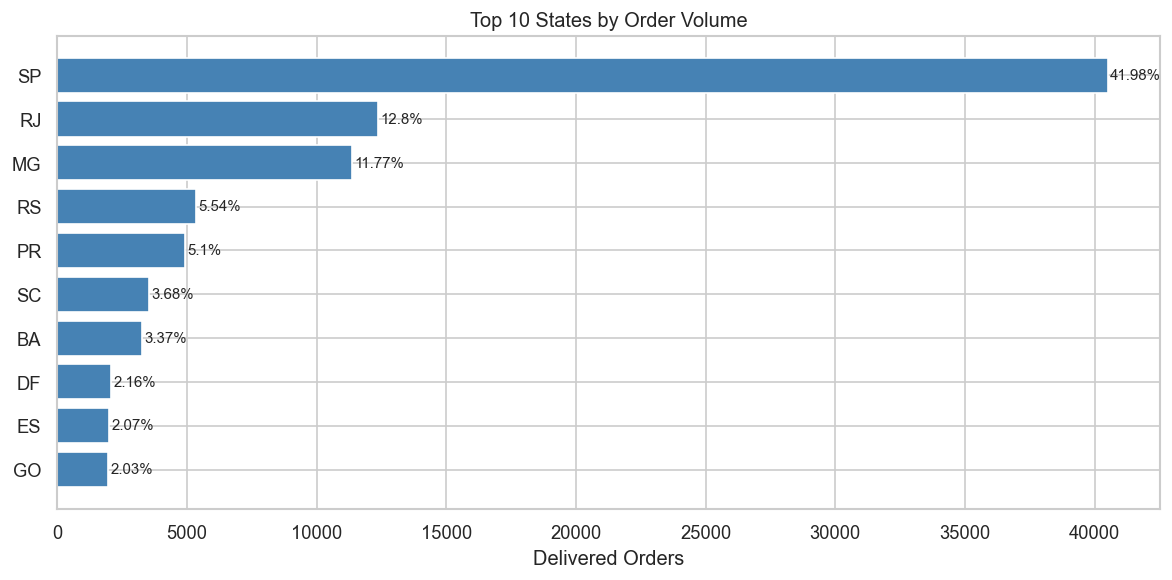

In [6]:
q = """
SELECT
    c.customer_state                                           AS state,
    COUNT(DISTINCT o.order_id)                                 AS orders,
    ROUND(100.0 * COUNT(DISTINCT o.order_id)
          / SUM(COUNT(DISTINCT o.order_id)) OVER (), 2)        AS pct
FROM olist_orders    o
JOIN olist_customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
"""
geo = sql(q)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(geo["state"][::-1], geo["orders"][::-1], color="steelblue")
for bar, pct in zip(bars, geo["pct"][::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=9)
ax.set_xlabel("Delivered Orders")
ax.set_title("Top 10 States by Order Volume")
plt.tight_layout()
plt.show()

In [7]:
q = """
WITH customer_order_count AS (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM olist_orders    o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    GROUP BY 1
)
SELECT
    COUNT(*)                                                            AS total_customers,
    SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)                   AS repeat_customers,
    ROUND(100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)
          / COUNT(*), 2)                                                AS repeat_rate_pct,
    ROUND(AVG(order_count), 3)                                          AS avg_orders_per_customer,
    MAX(order_count)                                                    AS max_orders
FROM customer_order_count
"""
sql(q).T.rename(columns={0: "Value"})

,Value
total_customers,"96,096.00"
repeat_customers,"2,997.00"
repeat_rate_pct,3.12
avg_orders_per_customer,1.03
max_orders,17.00


In [8]:
q = """
WITH customer_ltv AS (
    SELECT
        c.customer_unique_id,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS ltv
    FROM olist_orders      o
    JOIN olist_order_items oi ON o.order_id   = oi.order_id
    JOIN olist_customers    c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
),
bucketed AS (
    SELECT ltv, NTILE(4) OVER (ORDER BY ltv) AS q
    FROM customer_ltv
)
SELECT
    CASE q WHEN 1 THEN 'Q1 Bottom 25%' WHEN 2 THEN 'Q2'
            WHEN 3 THEN 'Q3'           WHEN 4 THEN 'Q4 Top 25%' END AS segment,
    COUNT(*)                  AS customers,
    ROUND(MIN(ltv), 2)        AS min_ltv,
    ROUND(AVG(ltv), 2)        AS avg_ltv,
    ROUND(MAX(ltv), 2)        AS max_ltv
FROM bucketed
GROUP BY q
ORDER BY q
"""
sql(q)

,segment,customers,min_ltv,avg_ltv,max_ltv
0,Q1 Bottom 25%,23340,9.59,43.58,63.01
1,Q2,23340,63.01,83.53,107.78
2,Q3,23339,107.78,140.95,182.51
3,Q4 Top 25%,23339,182.52,392.62,"13,664.08"


## Section 3：賣家績效排名（Window Function：RANK）

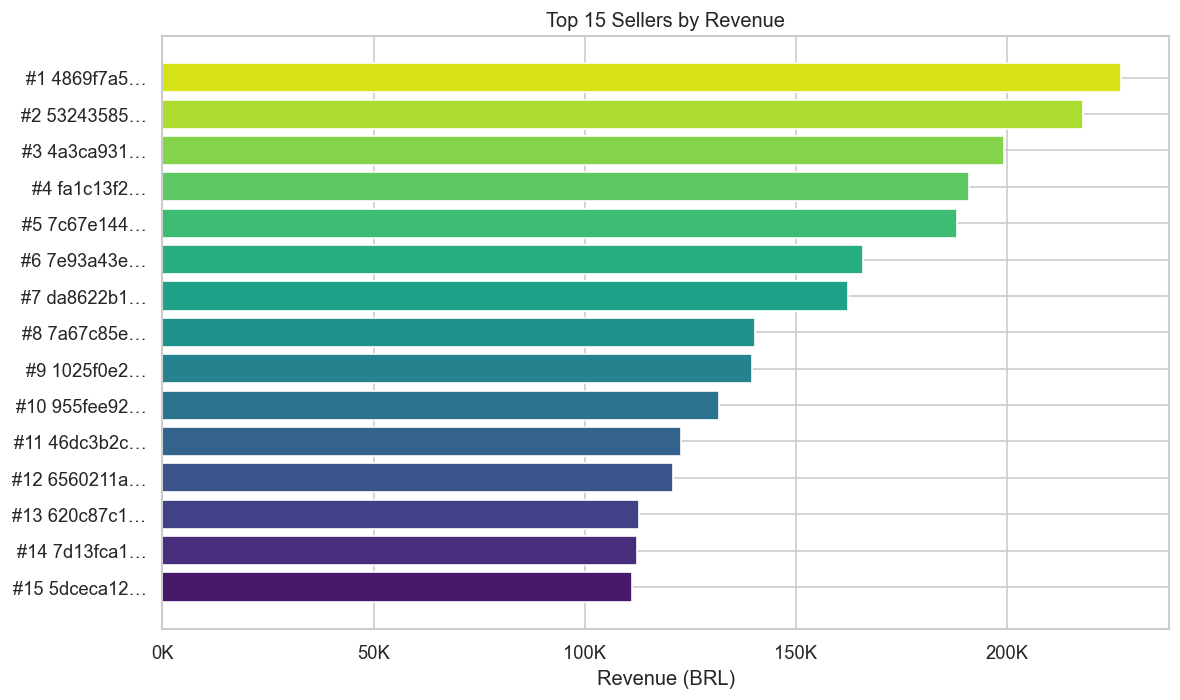

,rank,seller_id,seller_city,seller_state,revenue,orders,avg_score
0,1,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,"226,988.00",1124,4.14
1,2,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,"217,940.00",348,4.13
2,3,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,"199,408.00",1772,3.83
3,4,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,"190,917.00",578,4.37
4,5,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,"188,064.00",973,3.35
5,6,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,"165,981.00",319,4.36
6,7,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,"162,304.00",1311,4.08
7,8,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,"140,239.00",1145,4.27
8,9,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,"139,720.00",910,3.87
9,10,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,"131,907.00",1261,4.09


In [9]:
q = """
WITH seller_stats AS (
    SELECT
        s.seller_id,
        s.seller_city,
        s.seller_state,
        ROUND(SUM(oi.price), 0)           AS revenue,
        COUNT(DISTINCT oi.order_id)        AS orders,
        ROUND(AVG(r.review_score), 2)      AS avg_score
    FROM olist_sellers          s
    JOIN olist_order_items      oi ON s.seller_id  = oi.seller_id
    JOIN olist_orders            o ON oi.order_id   = o.order_id
    LEFT JOIN olist_order_reviews r ON o.order_id   = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2, 3
)
SELECT
    RANK() OVER (ORDER BY revenue DESC) AS rank,
    seller_id,
    seller_city,
    seller_state,
    revenue,
    orders,
    avg_score
FROM seller_stats
ORDER BY revenue DESC
LIMIT 15
"""
sellers = sql(q)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"#{r} {sid[:8]}…" for r, sid in zip(sellers["rank"], sellers["seller_id"])]
ax.barh(labels[::-1], sellers["revenue"][::-1],
        color=sns.color_palette("viridis", len(sellers)))
ax.set_xlabel("Revenue (BRL)")
ax.set_title("Top 15 Sellers by Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()
sellers

## Section 4：商品品類分析（多表 JOIN）

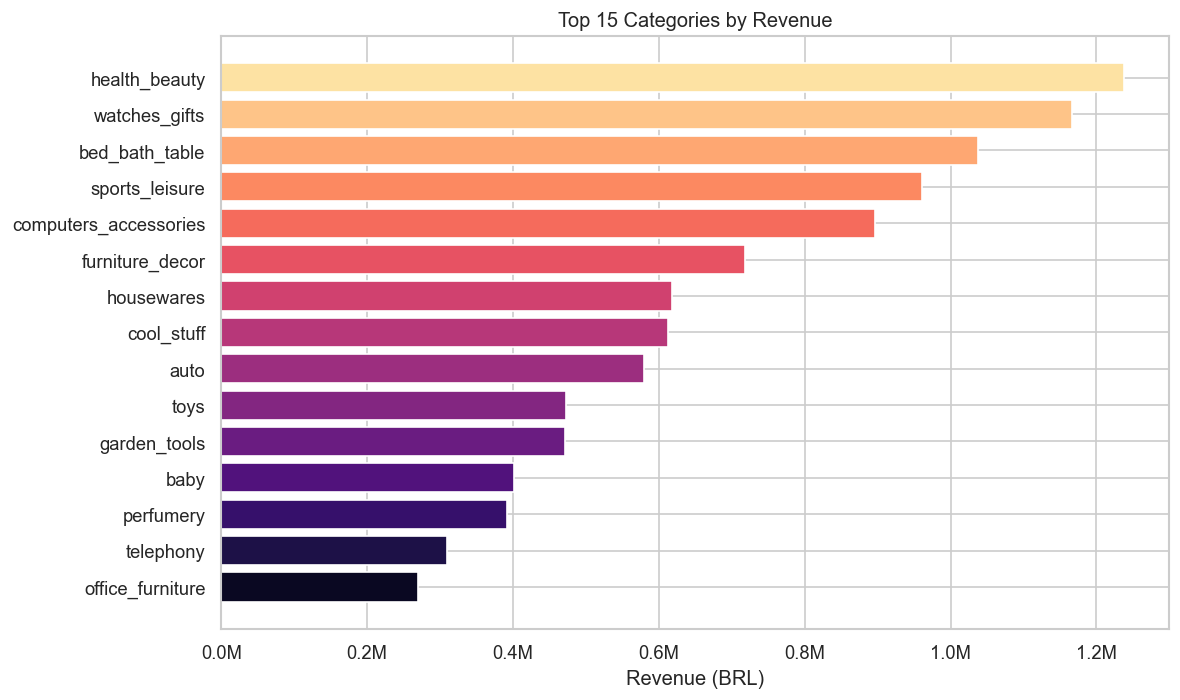

,category,orders,revenue,avg_price,avg_score
0,health_beauty,8647,"1,237,440.00",130.00,4.19
1,watches_gifts,5495,"1,167,247.00",198.88,4.07
2,bed_bath_table,9272,"1,037,178.00",93.38,3.92
3,sports_leisure,7530,"960,189.00",113.11,4.17
4,computers_accessories,6530,"896,243.00",116.27,3.98
5,furniture_decor,6307,"718,345.00",87.19,3.95
6,housewares,5743,"617,837.00",90.61,4.11
7,cool_stuff,3559,"612,072.00",164.23,4.19
8,auto,3810,"580,263.00",139.55,4.12
9,toys,3804,"472,110.00",116.92,4.21


In [10]:
q = """
SELECT
    COALESCE(t.product_category_name_english,
             p.product_category_name)       AS category,
    COUNT(DISTINCT o.order_id)              AS orders,
    ROUND(SUM(oi.price), 0)                 AS revenue,
    ROUND(AVG(oi.price), 2)                 AS avg_price,
    ROUND(AVG(r.review_score), 2)           AS avg_score
FROM olist_order_items        oi
JOIN olist_products             p  ON oi.product_id = p.product_id
JOIN olist_orders               o  ON oi.order_id   = o.order_id
LEFT JOIN category_translation  t  ON p.product_category_name = t.product_category_name
LEFT JOIN olist_order_reviews   r  ON o.order_id               = r.order_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL
GROUP BY 1
ORDER BY revenue DESC
LIMIT 15
"""
cats = sql(q)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cats["category"][::-1], cats["revenue"][::-1],
        color=sns.color_palette("magma", len(cats)))
ax.set_xlabel("Revenue (BRL)")
ax.set_title("Top 15 Categories by Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()
cats

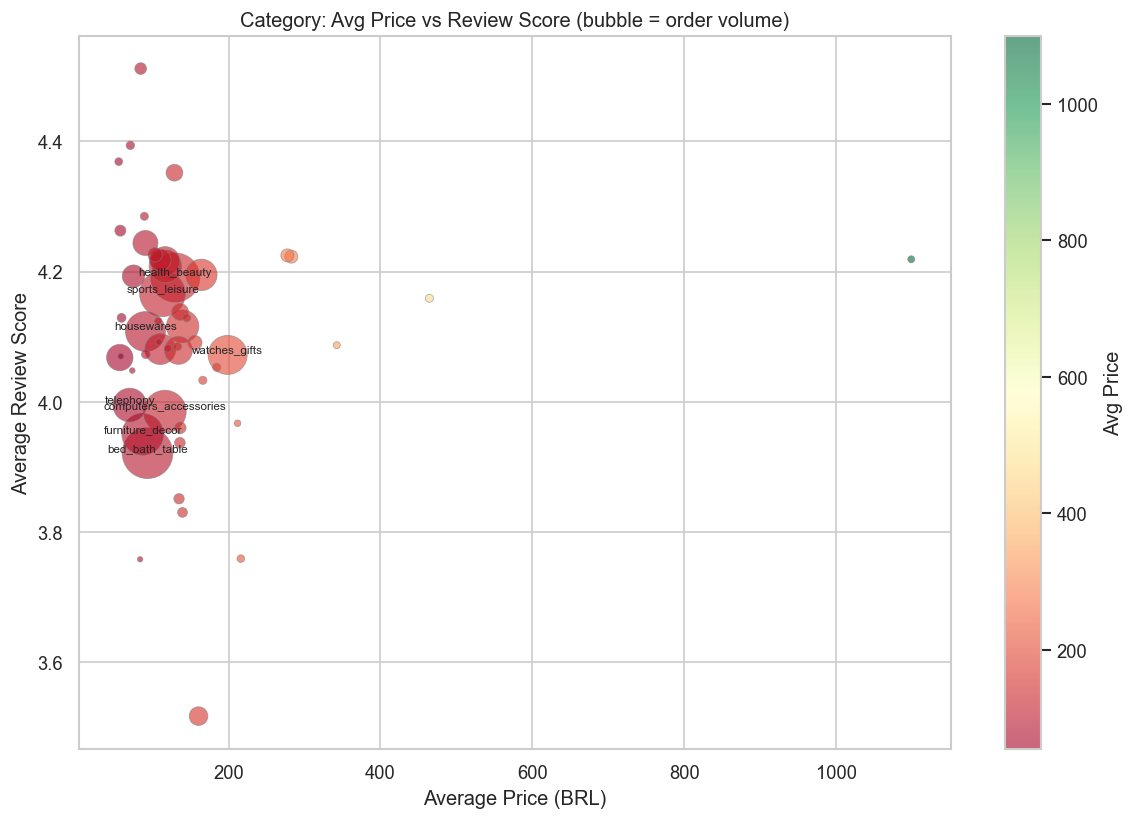

In [11]:
q = """
SELECT
    COALESCE(t.product_category_name_english,
             p.product_category_name)       AS category,
    ROUND(AVG(oi.price), 2)                 AS avg_price,
    ROUND(AVG(r.review_score), 3)           AS avg_score,
    COUNT(DISTINCT o.order_id)              AS orders
FROM olist_order_items        oi
JOIN olist_products             p  ON oi.product_id = p.product_id
JOIN olist_orders               o  ON oi.order_id   = o.order_id
LEFT JOIN category_translation  t  ON p.product_category_name = t.product_category_name
LEFT JOIN olist_order_reviews   r  ON o.order_id               = r.order_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL
GROUP BY 1
HAVING orders >= 100
ORDER BY orders DESC
"""
sc = sql(q)

fig, ax = plt.subplots(figsize=(10, 7))
scat = ax.scatter(sc["avg_price"], sc["avg_score"],
                  s=sc["orders"] / 10, alpha=0.6,
                  c=sc["avg_price"], cmap="RdYlGn",
                  edgecolors="grey", linewidths=0.5)
for _, row in sc.nlargest(8, "orders").iterrows():
    ax.annotate(row["category"], (row["avg_price"], row["avg_score"]),
                fontsize=7, ha="center", va="bottom")
ax.set_xlabel("Average Price (BRL)")
ax.set_ylabel("Average Review Score")
ax.set_title("Category: Avg Price vs Review Score (bubble = order volume)")
plt.colorbar(scat, label="Avg Price")
plt.tight_layout()
plt.show()

## Section 5：物流分析

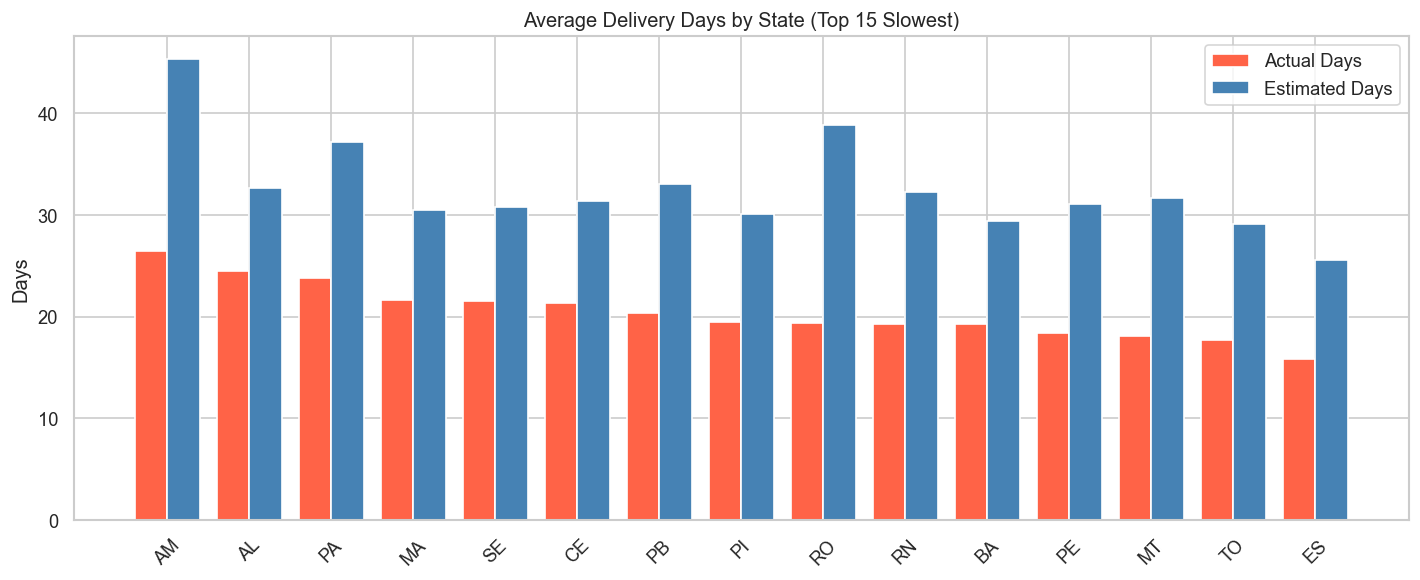

In [12]:
q = """
SELECT
    c.customer_state                                                         AS state,
    COUNT(*)                                                                 AS orders,
    ROUND(AVG(JULIANDAY(o.order_delivered_customer_date)
              - JULIANDAY(o.order_purchase_timestamp)), 1)                   AS avg_actual_days,
    ROUND(AVG(JULIANDAY(o.order_estimated_delivery_date)
              - JULIANDAY(o.order_purchase_timestamp)), 1)                   AS avg_estimated_days
FROM olist_orders    o
JOIN olist_customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY 1
HAVING orders >= 100
ORDER BY avg_actual_days DESC
LIMIT 15
"""
dv = sql(q)

x = range(len(dv))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - 0.2 for i in x], dv["avg_actual_days"],    width=0.4, label="Actual Days",    color="tomato")
ax.bar([i + 0.2 for i in x], dv["avg_estimated_days"], width=0.4, label="Estimated Days", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(dv["state"], rotation=45)
ax.set_ylabel("Days")
ax.set_title("Average Delivery Days by State (Top 15 Slowest)")
ax.legend()
plt.tight_layout()
plt.show()

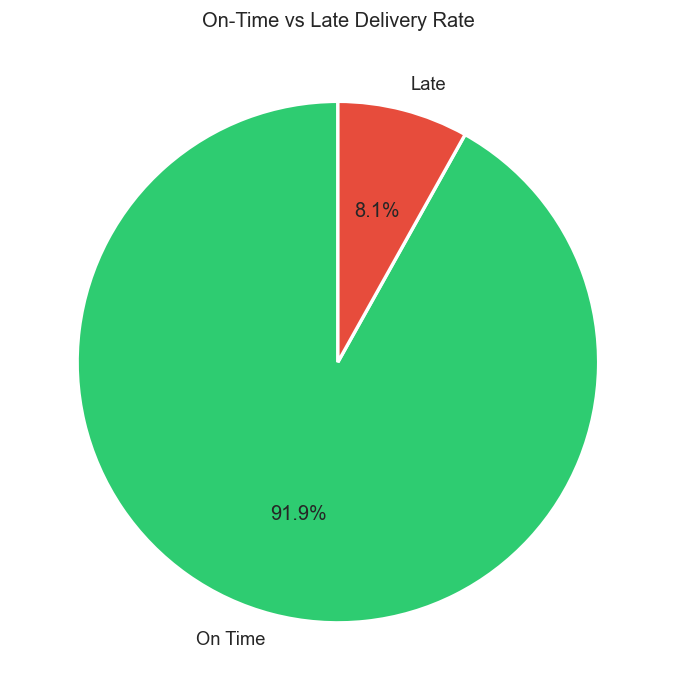

,status,orders,pct
0,On Time,88644,91.89
1,Late,7826,8.11


In [13]:
q = """
WITH flags AS (
    SELECT
        CASE
            WHEN order_delivered_customer_date <= order_estimated_delivery_date THEN 'On Time'
            ELSE 'Late'
        END AS status
    FROM olist_orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
)
SELECT
    status,
    COUNT(*)                                                    AS orders,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)          AS pct
FROM flags
GROUP BY 1
ORDER BY orders DESC
"""
ot = sql(q)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(ot["orders"], labels=ot["status"], autopct="%1.1f%%",
       colors=["#2ecc71", "#e74c3c"], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("On-Time vs Late Delivery Rate")
plt.tight_layout()
plt.show()
ot

## Section 6：評分分析

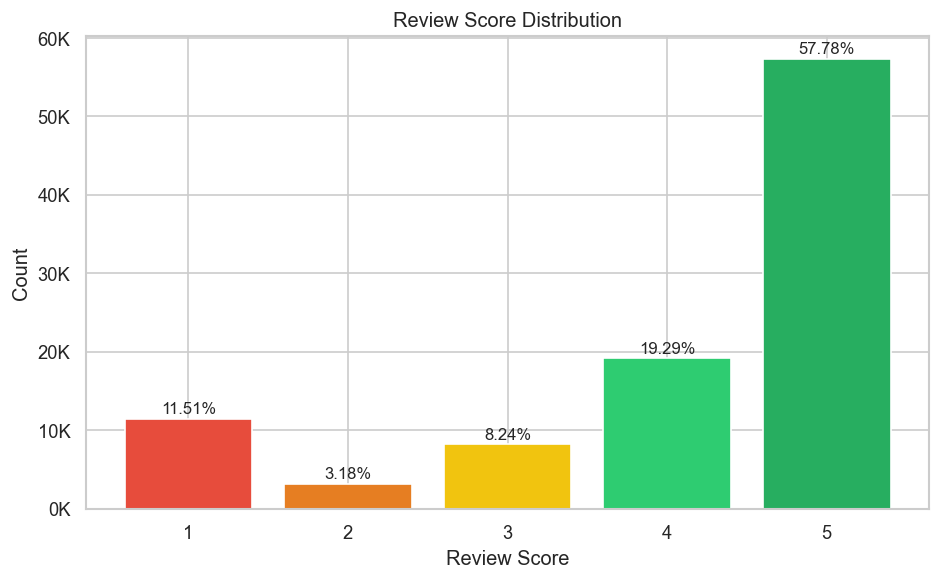

In [14]:
q = """
SELECT
    review_score,
    COUNT(*)                                                    AS count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)          AS pct
FROM olist_order_reviews
GROUP BY 1
ORDER BY 1
"""
scores = sql(q)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
bars = ax.bar(scores["review_score"].astype(str), scores["count"], color=colors)
for bar, pct in zip(bars, scores["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{pct}%", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Review Score")
ax.set_ylabel("Count")
ax.set_title("Review Score Distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

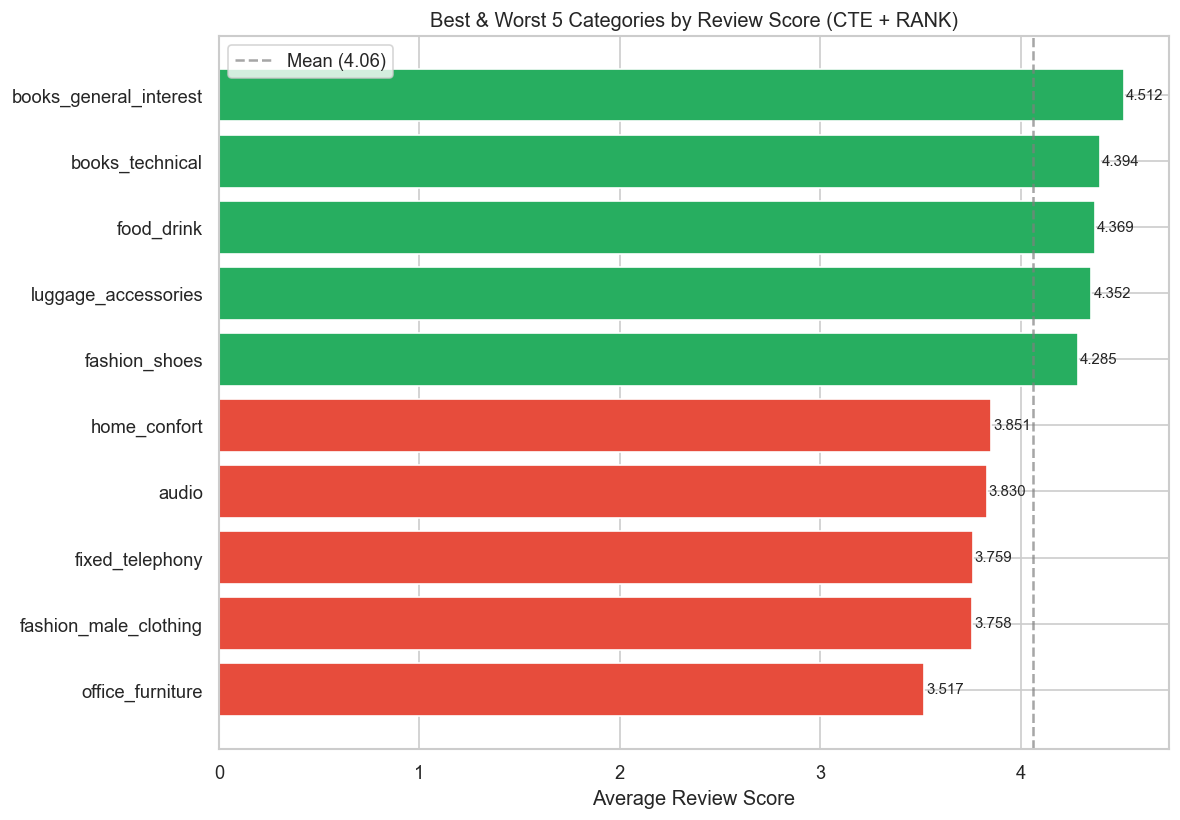

,category,avg_score,reviews,tier
0,books_general_interest,4.51,533,Top 5
1,books_technical,4.39,264,Top 5
2,food_drink,4.37,271,Top 5
3,luggage_accessories,4.35,1073,Top 5
4,fashion_shoes,4.29,256,Top 5
5,home_confort,3.85,430,Bottom 5
6,audio,3.83,359,Bottom 5
7,fixed_telephony,3.76,253,Bottom 5
8,fashion_male_clothing,3.76,124,Bottom 5
9,office_furniture,3.52,1664,Bottom 5


In [15]:
q = """
WITH category_scores AS (
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name)       AS category,
        ROUND(AVG(r.review_score), 3)            AS avg_score,
        COUNT(r.review_id)                       AS reviews
    FROM olist_order_reviews       r
    JOIN olist_orders               o  ON r.order_id    = o.order_id
    JOIN olist_order_items         oi  ON o.order_id    = oi.order_id
    JOIN olist_products             p  ON oi.product_id = p.product_id
    LEFT JOIN category_translation  t  ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    HAVING reviews >= 100
),
ranked AS (
    SELECT *,
           RANK() OVER (ORDER BY avg_score DESC) AS rank_top,
           RANK() OVER (ORDER BY avg_score ASC)  AS rank_bottom
    FROM category_scores
)
SELECT category, avg_score, reviews,
       CASE WHEN rank_top    <= 5 THEN 'Top 5'
            WHEN rank_bottom <= 5 THEN 'Bottom 5'
       END AS tier
FROM ranked
WHERE rank_top <= 5 OR rank_bottom <= 5
ORDER BY avg_score DESC
"""
ranking = sql(q)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#27ae60" if t == "Top 5" else "#e74c3c" for t in ranking["tier"][::-1]]
bars = ax.barh(ranking["category"][::-1], ranking["avg_score"][::-1], color=colors)
for bar, score in zip(bars, ranking["avg_score"][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}", va="center", fontsize=9)
mean_score = ranking["avg_score"].mean()
ax.axvline(x=mean_score, color="grey", linestyle="--", alpha=0.7, label=f"Mean ({mean_score:.2f})")
ax.set_xlabel("Average Review Score")
ax.set_title("Best & Worst 5 Categories by Review Score (CTE + RANK)")
ax.legend()
plt.tight_layout()
plt.show()
ranking